<a href="https://colab.research.google.com/github/cafauzi13/Sentiment-Analysis-M-Paspor-PBA/blob/main/QUIZ_PBA_Annisa_Nur_Fauzi_228.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scrapping

In [44]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import time
import random
import re

url_berita = [
    "https://www.cnn.com/2026/03/30/climate/data-centers-are-having-an-underrported",
    "https://ucalgary.ca/sustainability/mobilizing-alberta/climate-action-blogs/will-ai-data-centres-raise-water-and-power-use-alberta",
    "https://www.newscientist.com/article/2521256-ai-data-centres-can-warm-surrounding-areas-by-up-to-9-1c/",
    "https://www.climatechangenews.com/2026/03/03/explainer-will-ai-data-centres-make-or-break-the-energy-transition/",
    "https://www.globalgovernmentforum.com/data-centres-threaten-uks-ability-to-meet-climate-targets-fear-mps/"

]

print(f"✅ Menyiapkan {len(url_berita)} link berita pilihan.")



✅ Menyiapkan 5 link berita pilihan.


DEFINISI FUNGSI CLEANING

In [45]:

def bersihkan_teks(teks):
    if not isinstance(teks, str):
        return ""

    # Hapus enter, tab, dan spasi berlebih
    teks = re.sub(r'[\n\r\t]', ' ', teks)
    # Hapus URL
    teks = re.sub(r'http[s]?://\S+', '', teks)
    # Hapus karakter non-ASCII (simbol aneh)
    teks = teks.encode("ascii", "ignore").decode()
    # Sisakan huruf, angka, dan tanda baca dasar
    teks = re.sub(r'[^a-zA-Z0-9.,!?%()"\'-]', ' ', teks)
    # Rapikan spasi berlebih
    teks = re.sub(r'\s+', ' ', teks)

    return teks.strip()


In [46]:
kumpulan_data = []
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

print("🚀 Mulai scraping berita...")

for i, url in enumerate(url_berita):
    print(f"[{i+1}/5] Mengambil data dari: {url[:50]}...")

    try:
        response = requests.get(url, headers=headers, timeout=15)
        if response.status_code == 200:
            soup = BeautifulSoup(response.content, 'html.parser')

            # Ambil judul berita (biasanya di tag h1)
            judul = soup.find('h1').get_text().strip() if soup.find('h1') else "No Title"

            # Ambil isi paragraf
            paragraf_html = soup.find_all('p')
            isi_berita = [p.get_text().strip() for p in paragraf_html if len(p.get_text().strip()) > 20]
            full_text = " ".join(isi_berita)

            # Cleaning
            teks_bersih = bersihkan_teks(full_text)

            if len(teks_bersih) > 200:
                kumpulan_data.append({
                    'No': i+1,
                    'URL': url,
                    'Judul': judul,
                    'Isi_Berita_Clean': teks_bersih
                })
            else:
                print(f"⚠️ Teks berita {i+1} terlalu pendek, mungkin terkena paywall/proteksi.")
        else:
            print(f"❌ Gagal akses {url}. Status code: {response.status_code}")

    except Exception as e:
        print(f"❌ Error pada link {i+1}: {e}")

    # Delay agar tidak diblokir
    time.sleep(random.uniform(2, 4))



🚀 Mulai scraping berita...
[1/5] Mengambil data dari: https://www.cnn.com/2026/03/30/climate/data-center...
[2/5] Mengambil data dari: https://ucalgary.ca/sustainability/mobilizing-albe...
[3/5] Mengambil data dari: https://www.newscientist.com/article/2521256-ai-da...
[4/5] Mengambil data dari: https://www.climatechangenews.com/2026/03/03/expla...
[5/5] Mengambil data dari: https://www.globalgovernmentforum.com/data-centres...


In [47]:
if kumpulan_data:
    df_hasil = pd.DataFrame(kumpulan_data)
    df_hasil.to_csv('berita_datacentre_clean.csv', index=False, encoding='utf-8')
    print("\n✅ SCRAPING SELESAI!")
    print(f"File disimpan sebagai: 'berita_datacentre_clean.csv'")

    # Tampilkan hasil
    display(df_hasil[['Judul', 'Isi_Berita_Clean']].head())
else:
    print("\n❌ Tidak ada data yang berhasil diambil.")


✅ SCRAPING SELESAI!
File disimpan sebagai: 'berita_datacentre_clean.csv'


,Judul,Isi_Berita_Clean
0,Scientists have found an alarming environmenta...,The vast data centers that power artificial in...
1,Will AI Data Centres Raise Water and Power Use...,Proposed Campus plan for Wonder Valley 40 km s...
2,AI data centres can warm surrounding areas by ...,Hundreds of millions of people live close enou...
3,Explainer: Will AI data centres make or break ...,Editing Helen Popper For tech entrepreneur Elo...
4,Data centres threaten UK’s ability to meet cli...,The UKs Environmental Audit Committee has rais...


# Soal 1 : Cari NER

In [48]:
import spacy
from spacy import displacy

nlp = spacy.load("en_core_web_sm")

print("✅ Model NLP en_core_web_sm berhasil dimuat!")

✅ Model NLP en_core_web_sm berhasil dimuat!


In [49]:
# Pastikan df_hasil memuat file yang baru disimpan
df_hasil = pd.read_csv('berita_datacentre_clean.csv')

# Ambil teks dari berita pertama (kolom Isi_Berita_Clean)
teks_sampel = df_hasil.iloc[0]['Isi_Berita_Clean']

# Proses teks dengan model NLP
doc = nlp(teks_sampel)

# List 10 entitas pertama
for ent in doc.ents[:10]:
    print(f"{ent.text:20} | {ent.label_}")

16 degrees           | QUANTITY
Fahrenheit           | ORG
more than 340 million | CARDINAL
Andrea Marinoni      | PERSON
Earth Observation    | ORG
the University of Cambridge | ORG
the last 20 years    | DATE
AI                   | GPE
thousands            | CARDINAL
the last decade      | DATE


In [50]:
# Loop untuk menampilkan NER dari berita 1 sampai 5
for i in range(len(df_hasil)):
    print(f"\n" + "="*50)
    print(f"📄 NER BERITA KE-{i+1}: {df_hasil.iloc[i]['Judul']}")
    print("="*50)

    # Ambil teks, proses, dan tampilkan
    doc_loop = nlp(df_hasil.iloc[i]['Isi_Berita_Clean'])
    displacy.render(doc_loop, style="ent", jupyter=True)


📄 NER BERITA KE-1: Scientists have found an alarming environmental impact of vast data centers



📄 NER BERITA KE-2: Will AI Data Centres Raise Water and Power Use in Alberta?



📄 NER BERITA KE-3: AI data centres can warm surrounding areas by up to 9.1°C



📄 NER BERITA KE-4: Explainer: Will AI data centres make or break the energy transition?



📄 NER BERITA KE-5: Data centres threaten UK’s ability to meet climate targets, fear MPs


Masih ada beberapa yang salah, misal: AI jadi GPE (negara)

In [51]:
from spacy.pipeline import EntityRuler

# 1. Tambahkan EntityRuler sebelum proses NER dimulai
if "entity_ruler" not in nlp.pipe_names:
    ruler = nlp.add_pipe("entity_ruler", before="ner")
    patterns = [
        {"label": "TECH", "pattern": "AI"},
        {"label": "TECH", "pattern": "data centers"},
        {"label": "TECH", "pattern": "algorithms"},
        {"label": "UNIT", "pattern": "Fahrenheit"},
        {"label": "UNIT", "pattern": "Celsius"},
        {"label": "ORG", "pattern": "Ofgem"}
    ]
    ruler.add_patterns(patterns)

print("✅ Aturan Tambahan Berhasil Diterapkan. Memulai Loop NER 'AFTER'...")

# 2. Loop NER Kedua (The "AFTER" Version)
for i in range(len(df_hasil)):
    print(f"\n" + "="*50)
    print(f"📄 NER (FIXED) BERITA KE-{i+1}: {df_hasil.iloc[i]['Judul']}")
    print("="*50)

    # Proses ulang teks dengan nlp yang sudah punya EntityRuler
    doc_after = nlp(df_hasil.iloc[i]['Isi_Berita_Clean'])
    displacy.render(doc_after, style="ent", jupyter=True)

✅ Aturan Tambahan Berhasil Diterapkan. Memulai Loop NER 'AFTER'...

📄 NER (FIXED) BERITA KE-1: Scientists have found an alarming environmental impact of vast data centers



📄 NER (FIXED) BERITA KE-2: Will AI Data Centres Raise Water and Power Use in Alberta?



📄 NER (FIXED) BERITA KE-3: AI data centres can warm surrounding areas by up to 9.1°C



📄 NER (FIXED) BERITA KE-4: Explainer: Will AI data centres make or break the energy transition?



📄 NER (FIXED) BERITA KE-5: Data centres threaten UK’s ability to meet climate targets, fear MPs


# Soal 2 : TextBlob

In [61]:
from textblob import TextBlob

# 1. Fungsi untuk analisis sentimen menggunakan TextBlob
def analyze_sentiment_textblob(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity  # Nilai antara -1 (negatif) dan 1 (positif)

# 2. Kategorikan sentimen berdasarkan nilai polaritas
def categorize_sentiment(polarity):
    if polarity > 0:
        return 'Positif'
    elif polarity < 0:
        return 'Negatif'
    else:
        return 'Netral'

# 3. Terapkan ke dataframe df_hasil (kolom Isi_Berita_Clean)
df_hasil['sentiment_textblob'] = df_hasil['Isi_Berita_Clean'].apply(analyze_sentiment_textblob)
df_hasil['sentiment_category_textblob'] = df_hasil['sentiment_textblob'].apply(categorize_sentiment)

# Tampilkan hasil analisis sentimen
print("--- Hasil Analisis Sentimen TextBlob ---")
display(df_hasil[['Judul', 'sentiment_textblob', 'sentiment_category_textblob']])

--- Hasil Analisis Sentimen TextBlob ---


,Judul,sentiment_textblob,sentiment_category_textblob
0,Scientists have found an alarming environmenta...,0.100144,Positif
1,Will AI Data Centres Raise Water and Power Use...,0.158549,Positif
2,AI data centres can warm surrounding areas by ...,0.143524,Positif
3,Explainer: Will AI data centres make or break ...,0.110429,Positif
4,Data centres threaten UK’s ability to meet cli...,0.130133,Positif


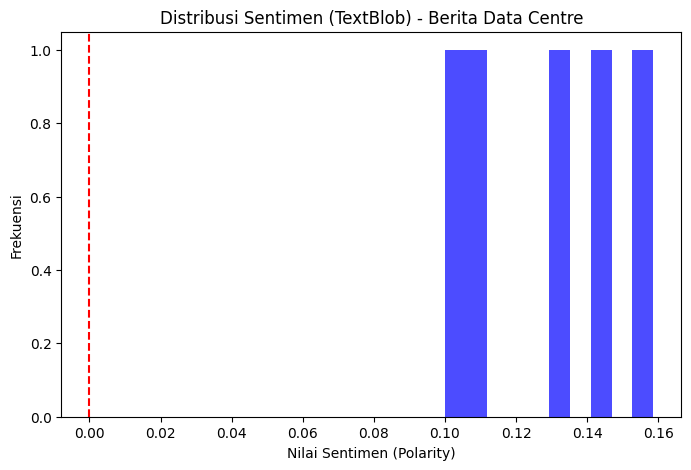

In [62]:
import matplotlib.pyplot as plt

# Visualisasi hasil analisis sentimen (Histogram)
plt.figure(figsize=(8, 5))
plt.hist(df_hasil['sentiment_textblob'], bins=10, color='blue', alpha=0.7)
plt.title('Distribusi Sentimen (TextBlob) - Berita Data Centre')
plt.xlabel('Nilai Sentimen (Polarity)')
plt.ylabel('Frekuensi')
plt.axvline(0, color='red', linestyle='--') # Garis bantu netral
plt.show()


Jumlah Artikel per Kategori:
sentiment_category_textblob
Positif    5
Name: count, dtype: int64


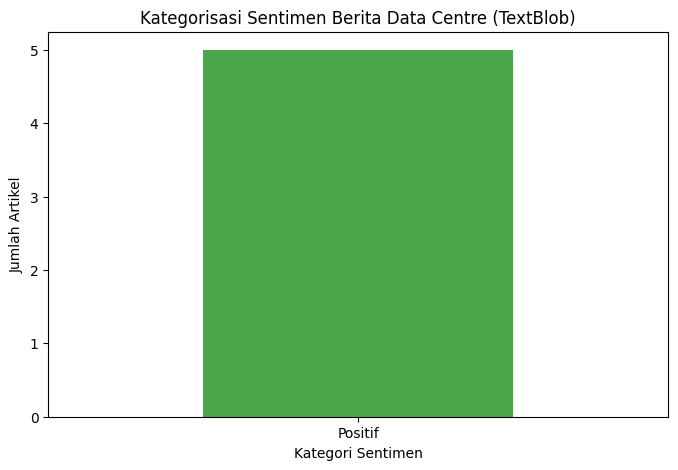

In [63]:
# Hitung jumlah artikel berdasarkan kategori sentimen
sentiment_counts_textblob = df_hasil['sentiment_category_textblob'].value_counts()

print("\nJumlah Artikel per Kategori:")
print(sentiment_counts_textblob)

# Visualisasi hasil kategorisasi sentimen (Bar Plot)
plt.figure(figsize=(8, 5))
# Kita sesuaikan urutan warna: Hijau (Positif), Merah (Negatif), Abu-abu (Netral)
colors = {'Positif': 'green', 'Negatif': 'red', 'Netral': 'gray'}
current_colors = [colors.get(x, 'blue') for x in sentiment_counts_textblob.index]

sentiment_counts_textblob.plot(kind='bar', color=current_colors, alpha=0.7)
plt.title('Kategorisasi Sentimen Berita Data Centre (TextBlob)')
plt.xlabel('Kategori Sentimen')
plt.ylabel('Jumlah Artikel')
plt.xticks(rotation=0)
plt.show()

karena positif semua (padahal apabila dibaca manual sentimennya tidak positif. Kemungkinan karena ada kata"dengan tone positif seperti "significant", "major", "advanced", dan "development") coba kita tambah keyword sendiri untuk scoring

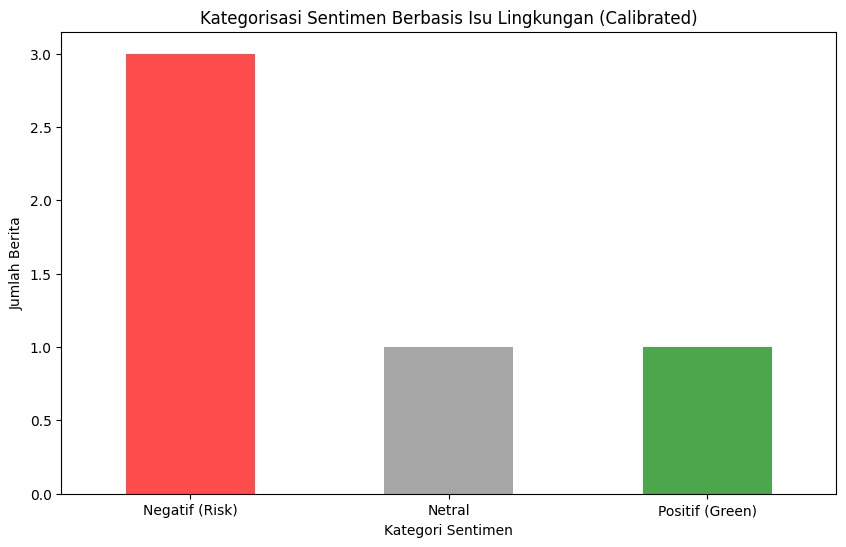

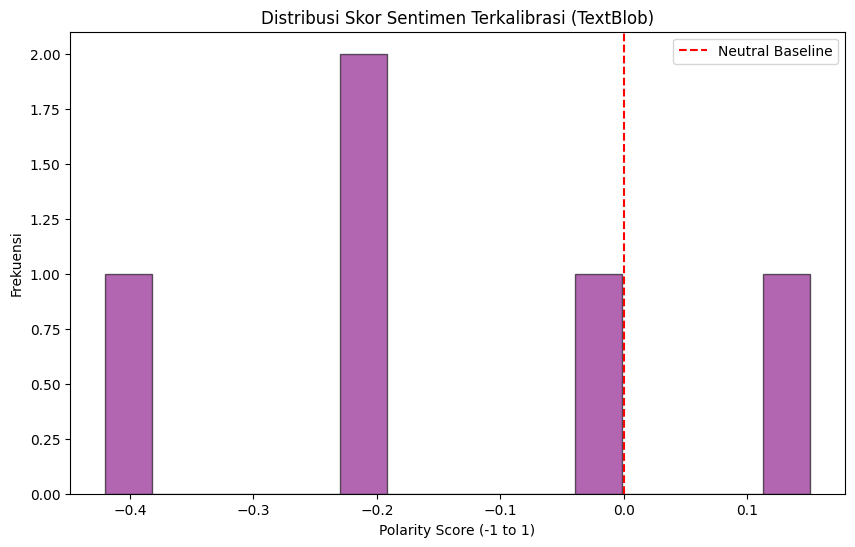

In [64]:
# 1. Definisikan Fungsi Analisis Sentimen Lingkungan
env_lexicon = {
    'risk': -0.7, 'threat': -0.7, 'warming': -0.8, 'heat': -0.5,
    'emissions': -0.6, 'alarming': -0.8, 'danger': -0.7, 'impact': -0.3,
    'concerns': -0.5, 'guzzle': -0.6, 'sustainable': 0.7, 'clean': 0.6
}

def analyze_env_sentiment(text):
    analysis = TextBlob(text)
    score = analysis.sentiment.polarity
    words = text.lower().split()
    adjustment = sum([env_lexicon[w] for w in words if w in env_lexicon])
    return max(min(score + (adjustment * 0.08), 1.0), -1.0) # Normalisasi

# 2. Terapkan ke Dataframe
df_hasil['sentiment_calibrated'] = df_hasil['Isi_Berita_Clean'].apply(analyze_env_sentiment)
df_hasil['category_calibrated'] = df_hasil['sentiment_calibrated'].apply(
    lambda x: 'Negatif (Risk)' if x < -0.05 else ('Positif (Green)' if x > 0.05 else 'Netral')
)

# 3. VISUALISASI 1: Bar Chart Kategori
plt.figure(figsize=(10, 6))
counts = df_hasil['category_calibrated'].value_counts()
colors = [('red' if x == 'Negatif (Risk)' else 'green' if x == 'Positif (Green)' else 'gray') for x in counts.index]

counts.plot(kind='bar', color=colors, alpha=0.7)
plt.title('Kategorisasi Sentimen Berbasis Isu Lingkungan (Calibrated)')
plt.ylabel('Jumlah Berita')
plt.xlabel('Kategori Sentimen')
plt.xticks(rotation=0)
plt.show()

# 4. VISUALISASI 2: Histogram Sebaran Skor
plt.figure(figsize=(10, 6))
plt.hist(df_hasil['sentiment_calibrated'], bins=15, color='purple', alpha=0.6, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', label='Neutral Baseline')
plt.title('Distribusi Skor Sentimen Terkalibrasi (TextBlob)')
plt.xlabel('Polarity Score (-1 to 1)')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()

# Soal 3 : TF-IDF

In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# 1. Ambil konten berita dari df_hasil (hasil scraping sebelumnya)
documents = df_hasil['Isi_Berita_Clean'].astype(str).tolist()

# 2. Pakai Stopwords English
stop_words_en = list(set(stopwords.words('english')))
# Tambahkan kata-kata umum yang sering muncul di berita tapi kurang penting
stop_words_en.extend(['said', 'also', 'could', 'would', 'new', 'year'])

# 3. Inisialisasi TF-IDF Vectorizer
# Kita ambil unigram (1 kata) dan bigram (2 kata)
vectorizer = TfidfVectorizer(max_features=20, ngram_range=(1,2), stop_words=stop_words_en)
tfidf_matrix = vectorizer.fit_transform(documents)

# 4. Ambil nama fitur dan skornya
feature_names = vectorizer.get_feature_names_out()
denselist = tfidf_matrix.todense().tolist()

# 5. Buat DataFrame untuk skor TF-IDF
tfidf_df = pd.DataFrame(denselist, columns=feature_names)

print("--- TOP 20 KEYWORDS (TF-IDF) ---")
# Menjumlahkan skor TF-IDF dari semua dokumen untuk melihat kata paling dominan
top_keywords = tfidf_df.sum().sort_values(ascending=False).head(20)
print(top_keywords)

--- TOP 20 KEYWORDS (TF-IDF) ---
data            2.940560
centres         1.517607
data centres    1.435595
ai              1.066806
power           0.836346
energy          0.781402
centre          0.713217
government      0.647310
data centre     0.610392
water           0.592119
electricity     0.514998
climate         0.498526
years           0.467206
around          0.447660
grid            0.428643
alberta         0.411847
demand          0.377459
ai data         0.376654
emissions       0.376516
use             0.329715
dtype: float64


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [57]:
from sklearn.feature_extraction.text import CountVectorizer

# 1. Ambil teks berita
texts = df_hasil['Isi_Berita_Clean'].dropna().tolist()

# 2. Buat CountVectorizer untuk Bigram (2 kata) dan Trigram (3 kata)
# ngram_range=(2,3) artinya hanya ambil 2-3 kata berurutan
vectorizer_ngram = CountVectorizer(ngram_range=(2,3), stop_words=stop_words_en, max_features=10)
X_ngram = vectorizer_ngram.fit_transform(texts)

# 3. Hitung frekuensi kemunculan
ngrams = vectorizer_ngram.get_feature_names_out()
counts = X_ngram.sum(axis=0).A1
ngram_freq = pd.DataFrame({'ngram': ngrams, 'count': counts}).sort_values(by='count', ascending=False)

print("\n--- TOP 10 N-GRAMS (Bigrams/Trigrams) ---")
display(ngram_freq)


--- TOP 10 N-GRAMS (Bigrams/Trigrams) ---


,ngram,count
9,data centres,82
7,data centre,28
1,ai data,16
5,climate change,14
6,data centers,10
2,ai data centres,8
4,carbon budget,6
3,around world,6
0,20 years,5
8,data centre projects,5


Visualisasi

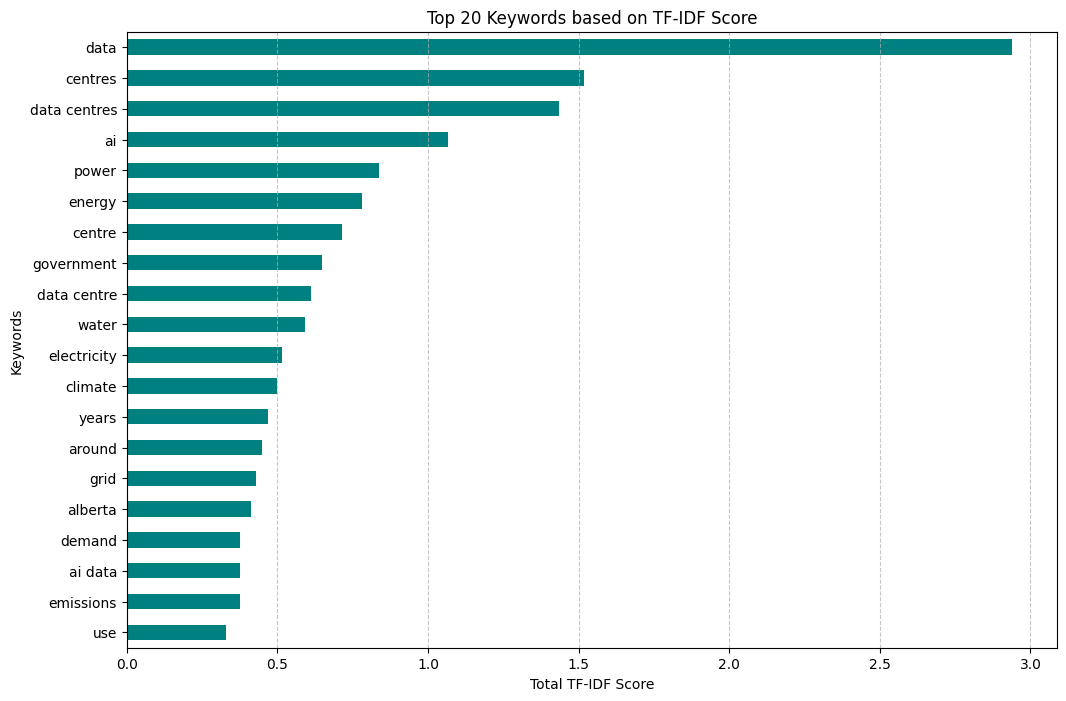

In [58]:
import matplotlib.pyplot as plt

# 1. Ambil 20 kata dengan skor TF-IDF tertinggi secara total
top_20_tfidf = tfidf_df.sum().sort_values(ascending=False).head(20)

# 2. Plotting Bar Chart
plt.figure(figsize=(12, 8))
top_20_tfidf.plot(kind='barh', color='teal')
plt.gca().invert_yaxis()  # Supaya skor tertinggi ada di paling atas
plt.title('Top 20 Keywords based on TF-IDF Score')
plt.xlabel('Total TF-IDF Score')
plt.ylabel('Keywords')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

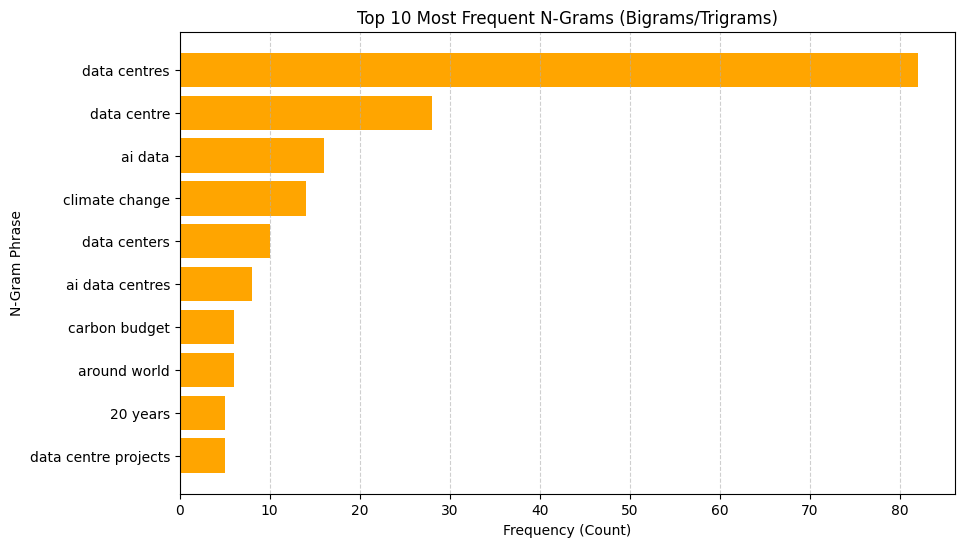

In [59]:
# Plotting Bar Chart untuk N-Gram
plt.figure(figsize=(10, 6))
plt.barh(ngram_freq['ngram'], ngram_freq['count'], color='orange')
plt.gca().invert_yaxis()
plt.title('Top 10 Most Frequent N-Grams (Bigrams/Trigrams)')
plt.xlabel('Frequency (Count)')
plt.ylabel('N-Gram Phrase')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

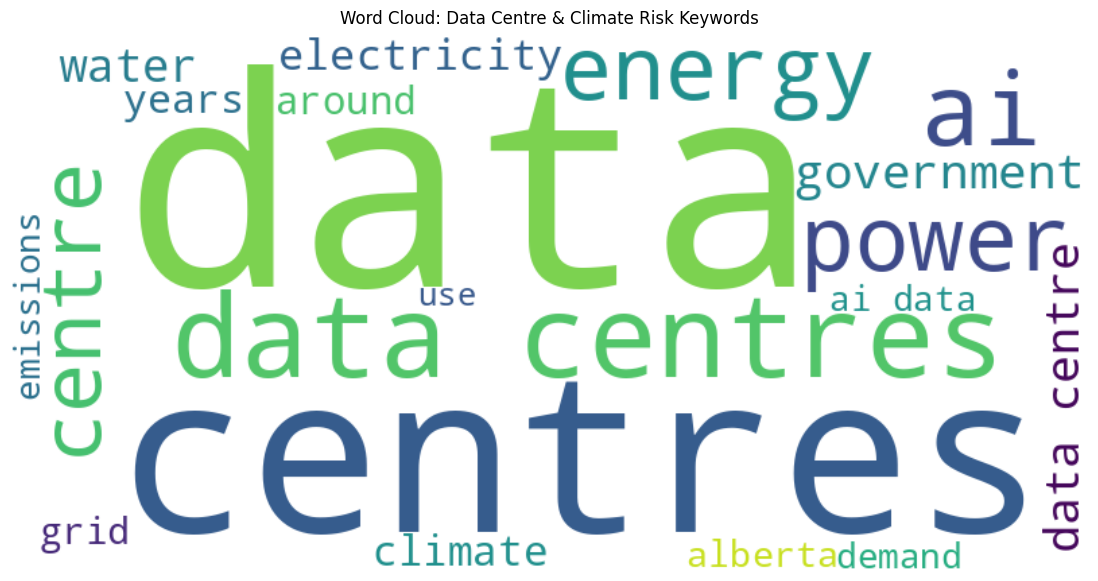

In [60]:
from wordcloud import WordCloud

# 1. Gabungkan semua skor TF-IDF jadi satu dictionary untuk WordCloud
tfidf_dict = tfidf_df.sum().to_dict()

# 2. Generate WordCloud
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='viridis').generate_from_frequencies(tfidf_dict)

# 3. Tampilkan
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Data Centre & Climate Risk Keywords')
plt.show()